#  Week 8: 3D plot and Matplotlib Animation
<img src="pic_W8/matplotliblogo.png" width=500>

##### by **2025/2026 LearnX+ Python Studio**



## Course Outcome

<div style="padding: 5px; border: 2px solid ; border-radius: 5 px;">

#### When we are done today you will be able to:

<div style="padding: 5px; border: 2px solid ; border-radius: 5 px;">

- make 3D plots
- Basic concept of simulation making
- Make a simulation
- add UI elements to simulation that update
</div>
</div>

## Main Reference
<a href="https://plotly.com/python/">
<img src="pic_W8/Plotly_webpage.png" width=500>
</a>
(click the image btw)

### Remember First download the library
<div style="padding: 10px; border: 2px solid ; border-radius: 5 px;">

`conda install plotly`

`conda install astropy`
</div>

## Plotly

Plotly is similar to matplotlib as it can be used to visualise data. However, we prefer to use plotly for 3D plot as it is more effiecent and performs much better than mpl3D

Yet again the basic concept is all the same as matplotlib only with slighly differing commands

In [ ]:
import plotly.graph_objects as go
import numpy as np
np.random.seed(1)

N = 70

fig = go.Figure(data=[go.Mesh3d(x=(70*np.random.randn(N)),
                   y=(55*np.random.randn(N)),
                   z=(40*np.random.randn(N)),
                   opacity=0.5,
                   color='rgba(244,22,100,0.6)'
                  )])

fig.update_layout(
    scene = dict(
        xaxis = dict(nticks=4, range=[-100,100],),
                     yaxis = dict(nticks=4, range=[-50,100],),
                     zaxis = dict(nticks=4, range=[-100,100],),),
    width=700,
    margin=dict(r=20, l=10, b=10, t=10))

fig.show()


### And the same as Matplotlib we can make subplots


In [59]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

fig = make_subplots(
    rows=2, cols=2,
    specs=[[{'type': 'xy'},      {'type': 'scene'}],
           [{'type': 'surface'}, {'type': 'domain'}]],
    subplot_titles=("2D Scatter", "3D Scatter", "3D Surface", "Pie Chart")
)

x = np.linspace(-5, 80, 10)
y = np.linspace(-5, 60, 10)
xGrid, yGrid = np.meshgrid(y, x)
z = xGrid ** 3 + yGrid ** 3

fig.add_trace(go.Scatter(y=[2, 3, 1]), row=1, col=1)

fig.add_trace(go.Scatter3d(x=x, y=y, z=x**3, mode='markers'), row=1, col=2)

fig.add_trace(
    go.Surface(x=x, y=y, z=z, colorscale='RdBu', showscale=False),
    row=2, col=1)

fig.add_trace(go.Pie(labels=['A', 'B'], values=[40, 60]), row=2, col=2)

fig.update_layout(
    title_text='Corrected Mixed Subplots',
    height=800,
    width=800,
    showlegend=False
)

fig.show()

### Plotly has many Types of 3D plots 

In [62]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

fig = make_subplots(
    rows=3, cols=3,
    specs=[[{'type': 'scene'}] * 3] * 3,
    subplot_titles=("3D Scatter (Synthetic)", "3D Surface (Wave)", "3D Bubble", 
                    "3D Line (Spiral)", "3D Mesh (Torus)", "Isosurface", 
                    "Volume", "Cone", "Streamtube")
)

t = np.linspace(0, 10, 100)
x_line, y_line, z_line = np.cos(t), np.sin(t), t # Spiral for Row 2, Col 1

x_surf = np.linspace(-5, 5, 50)
y_surf = np.linspace(-5, 5, 50)
x_grid, y_grid = np.meshgrid(x_surf, y_surf)
z_surf = np.sin(np.sqrt(x_grid**2 + y_grid**2))

fig.add_trace(go.Scatter3d(x=np.random.randn(50), y=np.random.randn(50), z=np.random.randn(50), mode='markers'), row=1, col=1)

fig.add_trace(go.Surface(z=z_surf, showscale=False), row=1, col=2)

fig.add_trace(go.Scatter3d(
    x=np.random.rand(20), y=np.random.rand(20), z=np.random.rand(20),
    mode='markers', marker=dict(size=np.random.rand(20)*20, color=np.random.rand(20), colorscale='Viridis')
), row=1, col=3)

fig.add_trace(go.Scatter3d(x=x_line, y=y_line, z=z_line, mode='lines', line=dict(width=4)), row=2, col=1)

u, v = np.mgrid[0:2*np.pi:20j, 0:2*np.pi:20j]
x_mesh = (3 + np.cos(v)) * np.cos(u)
y_mesh = (3 + np.cos(v)) * np.sin(u)
z_mesh = np.sin(v)
fig.add_trace(go.Mesh3d(x=x_mesh.flatten(), y=y_mesh.flatten(), z=z_mesh.flatten(), color='lightpink', opacity=0.50), row=2, col=2)

fig.add_trace(go.Isosurface(
    x=[0,0,0,0,1,1,1,1], y=[1,0,1,0,1,0,1,0], z=[1,1,0,0,1,1,0,0],
    value=[1,2,3,4,5,6,7,8], isomin=2, isomax=6, caps=dict(x_show=False, y_show=False)
), row=2, col=3)

X, Y, Z = np.mgrid[-1:1:30j, -1:1:30j, -1:1:30j]
vol_values = np.sin(np.pi*X) * np.cos(np.pi*Z) * np.sin(np.pi*Y)
fig.add_trace(go.Volume(
    x=X.flatten(), y=Y.flatten(), z=Z.flatten(), value=vol_values.flatten(),
    isomin=-0.1, isomax=0.8, opacity=0.1, surface_count=21
), row=3, col=1)

fig.add_trace(go.Cone(x=[1], y=[1], z=[1], u=[1], v=[1], w=[0]), row=3, col=2)

fig.add_trace(go.Streamtube(x=[0, 0, 0], y=[0, 1, 2], z=[0, 0, 0],
                                   u=[0, 0, 0], v=[1, 1, 1], w=[0, 0, 0]), row=3, col=3)

fig.update_layout(height=900, width=1000, title_text="Offline 3D Plot Examples", showlegend=False)
fig.show()

## Widgets

widgets can be used to make interactable elements that will update our graph
this include:
<div style="padding: 10px; border: 2px solid ; border-radius: 5 px;">

- slider
- button
- radio button
- input box
</div>

### When we make interactable elements we must follow a certain format to make sure the updates work properly

1. initialise everything (figures, axis, and create the slider)
2. update (update the values that the widgets control)
3. plot (use the updated value to create a new plot)



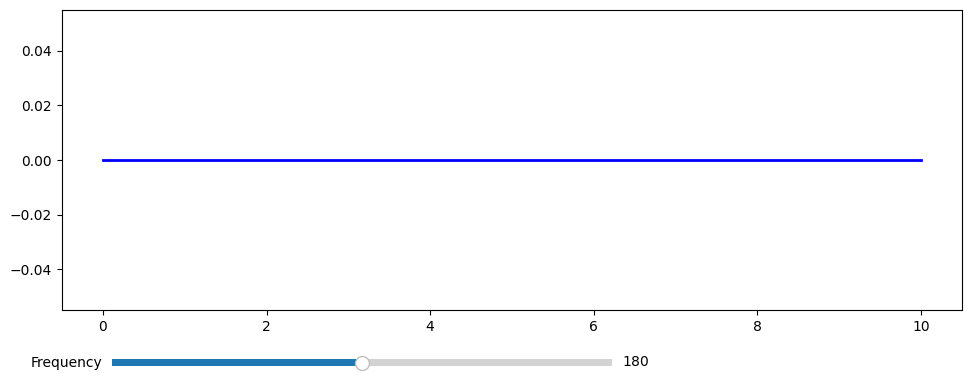

In [ ]:
### remember each step must be done in different functions 
### import as normal
import matplotlib.pyplot as plt
from matplotlib.widgets import Button, Slider, TextBox, RadioButtons
import numpy as np

### create a class to handle the interactive plot

class InteractivePlot:
    ### initialize the plot and widgets
    def initialize(self):
        ### our initial data
        self.w = 0
        self.x = np.linspace(0, 10, 100)
        self.y = np.sin(self.x*np.radians(self.w))
        ### create the figure and axis
        self.fig = plt.figure(figsize=(10,5))
        self.ax = plt.subplot2grid((1, 1), (0, 0))
        plt.subplots_adjust(left=0.05, right= 0.95, bottom=0.32, top=0.92, hspace=0.4)
        ### create the slider
        self.slider_ax = plt.axes([0.1, 0.2, 0.5, 0.03])
        self.slider = Slider(self.slider_ax, 'Frequency', 0, 360, valinit=180)
        ### when the sldier actually moves it will run the update function
        self.slider.on_changed(self.update)
        ### we make sure figure is plotted before we can update it
        self.plot()  
        
    ### then we update the value of w based on the slider value
    def update(self, w):
        self.w = self.slider.val
        ### we make sure the plot is updated with the new value of w
        self.plot()
        
    ### finally we create a function to plot the data
    
    def plot(self):
        ### we clear the axis before plotting the new data
        self.ax.clear()
        self.x = np.linspace(0, 10, 100)
        self.y = np.sin(self.x*np.radians(self.w))
        self.ax.plot(self.x, self.y, color='blue', linewidth=2)
        self.fig.canvas.draw_idle()

### now the initialization funtion happens everytime we run the code
InteractivePlot().initialize()
plt.show()


## Animation

Animation has the same base concept as Widgets 

1. Write the formula of the plot you want to animate
2. Do the update
3. Run the animation




In [ ]:
##Again remember to actually import the animation library
import matplotlib.pyplot as plt
import numpy as np 
import matplotlib.animation as animation

##STEP 1: Create the data to animate
y=np.array([0, 1, 2, 3, 4])
x=np.array([0, 1, 2, 3, 4])
fig, ax = plt.subplots()
line, = ax.plot(x, y)

###STEP 2: Make the Animation Update. This function will be called sequentially
def animate(i):
    line.set_data(x,np.sin(x + i / 10.0)) 
    return line,

###STEP 3: Call the animator. blit=True means only re-draw the parts that have changed.
ani = animation.FuncAnimation(fig, animate, interval=50, blit=True)

plt.show()

### NOW YOU ARE FINALLY READY TO MAKE A SIMULATION

#### lets start by doing a simple orbital motion simulation. Based on the launch velocity the object will either orbit, fall back down, or fly away.


In [ ]:
##Use this imports as a tip for what to do
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
from matplotlib.animation import FuncAnimation

###################### MOTION EQUATION ###############################
# Constants
G = 6.674e-11
M = 5.972e24
R_earth = 6.371e6

# 1. Physics Engine (Polar)
def get_orbit(v_start):
    dt = 10
    steps = 3000
    r = [R_earth + 1e6]
    theta = [0]
    vr = 0
    vtheta =  v_start / (R_earth + 1e6) 
    
    for _ in range(steps):
        curr_r = r[-1]
        if curr_r < R_earth: break        
        ar = curr_r * vtheta**2 - (G * M / curr_r**2)
        atheta = -2 * vr * vtheta / curr_r
        
        vr += ar * dt
        vtheta += atheta * dt
        
        r.append(curr_r + vr * dt)
        theta.append(theta[-1] + vtheta * dt)
        
    return np.array(theta), np.array(r)

###################### MOTION EQUATION ###############################

###Start by making your figure

### Use the 3 steps to create the animation (remember to use def)

### then use the 3 steps to make the ui (remember to use def)


plt.show()

## 🎉Congratulations🎉

You now how to plot in 3D when the time comes

You can also make simple simulations thats interactable

## Final word????

Remember that everything we learnt today is only the basics. As mentioned theres a lot of feature for this library that you must explore on your own. Todays class is so that when you do decide to use other feature, you wont be completely lost now that you have the basics.

### Always keep exploring.

